<div style="
    margin:40px 10px;
    padding:28px 30px;
    background:#07090c;
    border:2px solid #242931;
    box-shadow:
        8px 8px 0 #020304,
        15px 15px 30px rgba(0,0,0,0.8);
">

<div style="
    color:#ffffff;
    font-family:Impact,Arial Black,sans-serif;
    font-size:35px;
    letter-spacing:1px;
    text-shadow:
        3px 3px 0 #000000,
        6px 6px 0 #c7a52b;
">
INTRODUCTION TO GRADIO:
</div>

<div style="
    margin-top:8px;
    color:#c7a52b;
    font-family:Impact,Arial Black,sans-serif;
    font-size:22px;
    letter-spacing:2px;
">
WITH MATPLOTLIB AND PANDAS
</div>

<div style="
    margin-top:20px;
    height:3px;
    width:100%;
    background:#252a31;
">
<div style="
    width:28%;
    height:3px;
    background:#c7a52b;
    box-shadow:0 0 12px #c7a52b;
">
</div>
</div>

<div style="
    margin-top:15px;
    color:#707781;
    font-family:monospace;
    font-size:10px;
">
[ GRADIO DATABASE ] &nbsp; STATUS: ACTIVE
</div>

</div>

In [ ]:
# importing pandas and creating a data set:

import pandas as pd

# Sample data
data = {
    "Month": ["Jan", "Feb", "Mar", "Apr", "May", "Jun"],
    "Sales": [10000, 12000, 15000, 13000, 17000, 16000],
    "Profit": [2000, 3000, 4000, 2500, 3500, 3000]
}

df = pd.DataFrame(data)

In [2]:
df

,Month,Sales,Profit
0,Jan,10000,2000
1,Feb,12000,3000
2,Mar,15000,4000
3,Apr,13000,2500
4,May,17000,3500
5,Jun,16000,3000


In [3]:
import os
os.getcwd()

'c:\\Users\\shoai\\OneDrive\\Desktop\\Naresh IT Data Science\\Gradio'

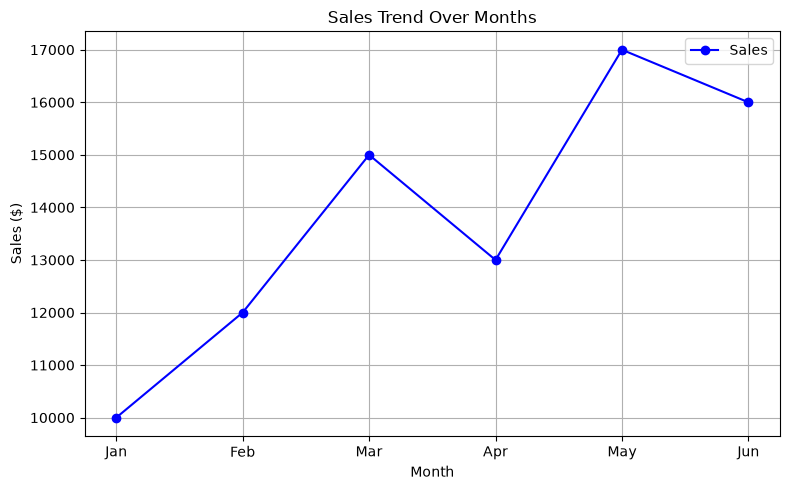

In [ ]:
# importing matplotlib and creating some graphs for gradio visualisation:

# 1- line plot: sales over time

import matplotlib.pyplot as plt

# Line Plot: Sales over time
plt.figure(figsize=(8,5))
plt.plot(df['Month'], df['Sales'], color='blue', marker='o', linestyle='-', label='Sales')
plt.title('Sales Trend Over Months')
plt.xlabel("Month")
plt.ylabel("Sales ($)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Output: A line plot showing the sales over the months


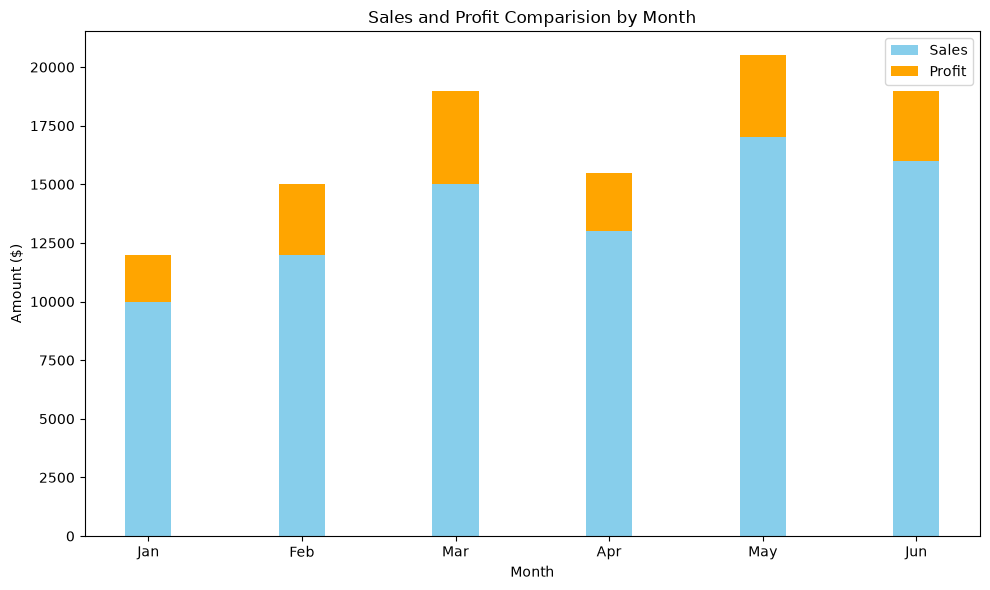

In [17]:
# Bar plot: sales vs profit by month
plt.figure(figsize=(10,6))
width = 0.3
plt.bar(df["Month"], df["Sales"], width=width, label = "Sales", color='skyblue')
plt.bar(df["Month"], df["Profit"], width=width, label = "Profit", color = 'orange', bottom=df['Sales'])
plt.title('Sales and Profit Comparision by Month')
plt.xlabel("Month")
plt.ylabel("Amount ($)")
plt.legend()
plt.tight_layout()
plt.show()

# this is a stacked bar plot where you can compare sales and profit
# for each month

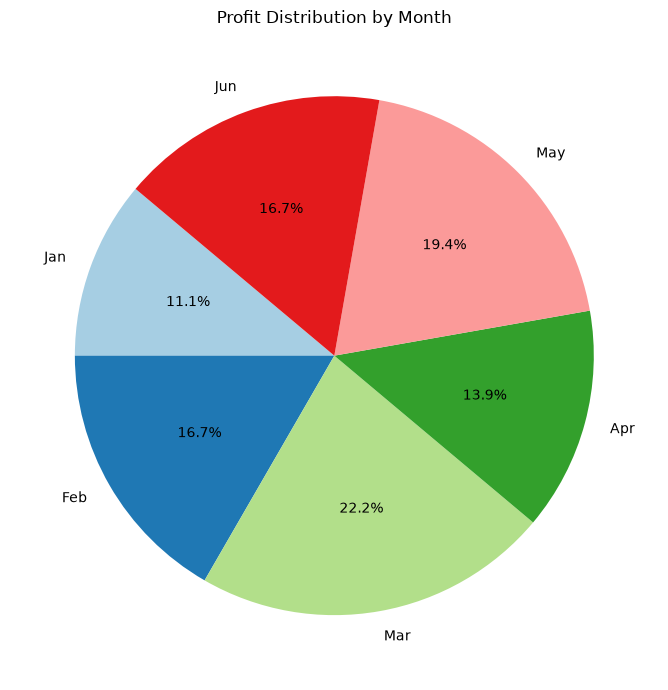

In [20]:
# Pie chart: Profit Distribution by Month
plt.figure(figsize=(7,7))
plt.pie(df['Profit'], labels= df["Month"], autopct= '%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)
plt.title("Profit Distribution by Month")
plt.tight_layout()
plt.show()

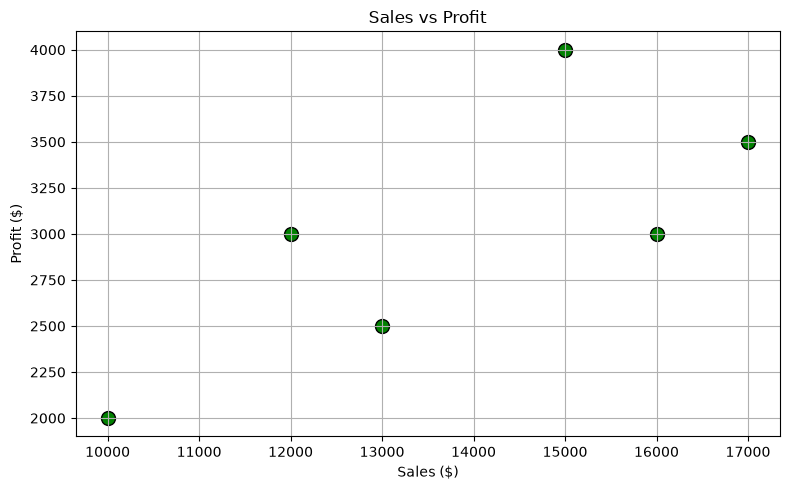

In [25]:
# Scatter Plot: Sales vs Profit (correlation)

plt.figure(figsize=(8,5))
plt.scatter(df["Sales"], df["Profit"], color = 'green', s = 100, edgecolors = 'black')
plt.title('Sales vs Profit')
plt.xlabel("Sales ($)")
plt.ylabel("Profit ($)")
plt.grid(True)
plt.tight_layout()
plt.show()

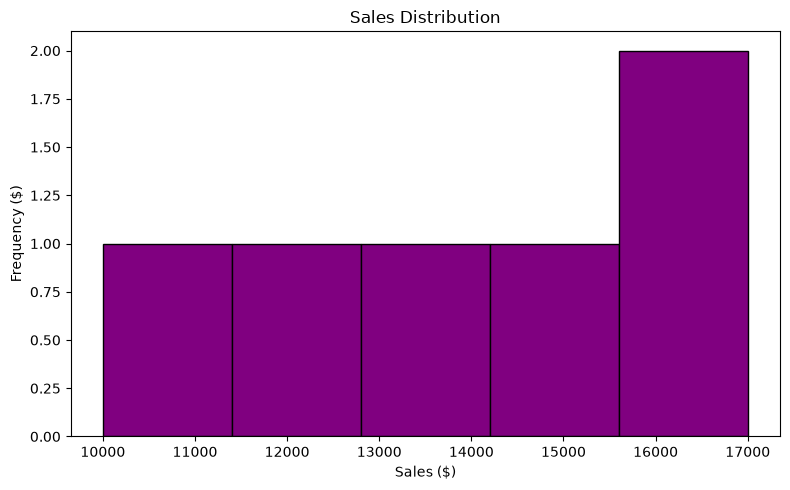

In [34]:
# Histogram: Distribution of Sales
plt.figure(figsize=(8,5))
plt.hist(df['Sales'], bins=5, color='purple', edgecolor='black')
plt.title("Sales Distribution")
plt.xlabel("Sales ($)")
plt.ylabel("Frequency ($)" )
plt.tight_layout()
plt.show()

C:\Users\shoai\AppData\Local\Temp\ipykernel_27572\2870655818.py:4: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df["Profit"], vert=False, patch_artist=True, boxprops=dict(facecolor="lightgreen"))


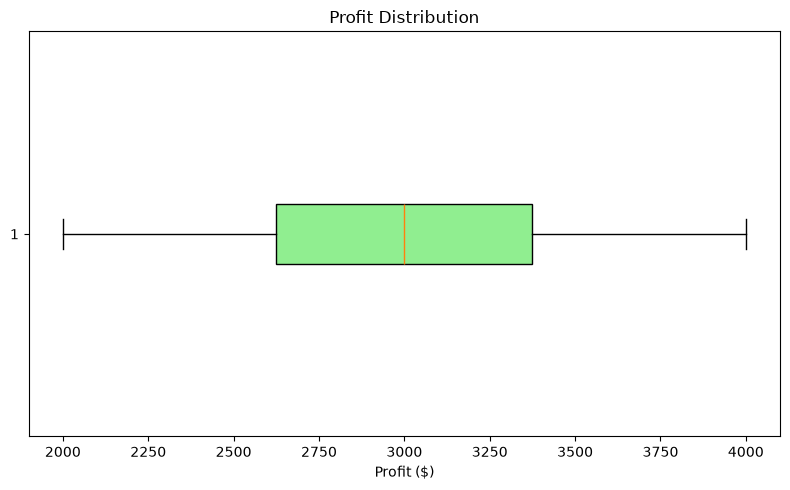

In [ ]:
# Box Plot: Profit Distribution

plt.figure(figsize=(8,5))
plt.boxplot(df["Profit"], vert=False, patch_artist=True, boxprops=dict(facecolor="lightgreen"))
plt.title("Profit Distribution")
plt.xlabel("Profit ($)")
plt.tight_layout()
plt.show()

# the output is box plot showing the spread and outliers of profit

In [4]:
pip install gradio

Note: you may need to restart the kernel to use updated packages.


In [5]:
import gradio as gr
import pandas as pd
import matplotlib.pyplot as plt

# sample data
data = {
    "Month": ["Jan", "Feb", "Mar", "Apr", "May", "Jun" ],
    "Sales": [10000, 12000, 15000, 13000, 17000, 16000],
    "Profit": [2000, 3000, 4000, 2500, 3500, 3000]
}

df = pd.DataFrame(data)

# Function to return selected plot
def generate_plot(Plot_type):
    fig = plt.figure(figsize=(8,5))

    if Plot_type == "Line Plot":
        plt.plot(df["Month"], df["Sales"], color= 'blue', marker='o', label='Sales')
        plt.title("Sales Trend OVer Months")
        plt.xlabel("Month")
        plt.ylabel("Sales ($)")
        plt.grid(True)
        plt.legend()

    elif Plot_type == "Stacked Bar Chart":
        fig.set_size_inches(10,6)
        width = 0.3
        plt.bar(df["Month"], df["Sales"], width=width, label = "Sales", color='skyblue')
        plt.bar(df["Month"], df["Profit"], width=width, label="Profit", color='orange', bottom=df["Sales"])
        plt.title("Sales and Profit Comparison by Month")
        plt.xlabel("Month")
        plt.ylabel("Amount ($)")
        plt.legend()

    elif Plot_type == "Pie Chart":
        fig.set_size_inches(7,7)
        plt.pie(df['Profit'], labels=df["Month"], autopct= '%1.1f%%', startangle=140, colors = plt.cm.Paired.colors)
        plt.title("Profit Distribution")

    elif Plot_type == "Scatter Plot":
        plt.scatter(df['Sales'], df['Profit'], color='green', s=100, edgecolors='black')
        plt.title('Sales vs Profit')
        plt.xlabel('Sales ($)')
        plt.ylabel('Profit ($)')
        plt.grid(True)

    elif Plot_type == "Histogram":
        plt.hist(df["Sales"], bins = 5, color = "purple", edgecolor = "black")
        plt.title("Sales Distribution")
        plt.xlabel('Sales ($)')
        plt.ylabel("Frequency")

    elif Plot_type ==  "Box Plot":
        plt.boxplot(df["Profit"], vert=False, patch_artist=True, boxprops=dict(facecolor='lightgreen'))
        plt.title("Profit Distribution")
        plt.xlabel("Profit ($)")

    plt.tight_layout()
    return fig

# Gradio UI

demo = gr.Interface(
    fn=generate_plot,
    inputs=gr.Radio(
        ["Line Plot", "Scatter Bar Chart", "Pie Chart", "Scatter Plot", "Histogram", "Box Plot" ],
        label="Choose Plot Type"
    ),
    outputs=gr.Plot(label="Visualization"),
    title="Sales & Profit Visual Explorer",
    description="Choose a chat type to visualtze the data"
)

demo.launch()

* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.
